# Reproducing Figure 3 of *Transformers Can Do Bayesian Inference* (Müller et al., ICLR 2022, arxiv 2112.10510)

Faithful reproduction of the 1D Gaussian-Process regression PPD figure inside `nanoTabPFN`.

Figure 3 shows, given two observed `(x, y)` points:
- **(a)** Heatmap of the PFN's posterior predictive distribution (PPD) over `y` as a function of query `x ∈ [0,1]` — the discretized **Riemann distribution** structure is visible.
- **(b)** PFN's mean and 95% confidence interval (blue) overlaid on the **exact** GP posterior (green) — nearly identical.

Setup follows paper §5.1: zero-mean GP with a fixed RBF kernel; sample `x ∼ U[0,1]`, then `y ∼ N(0, K)` where `K_{i,j} = k(x_i, x_j)`. Train PFN to predict held-out `y` on draws from this prior.

## 1. Imports and setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from model import NanoTabPFNModel, NanoTabPFNRegressor
from train import train, set_randomness_seed, get_default_device
from gp_prior import GPPriorDataLoader, sample_y_for_boundaries, gp_posterior
from riemann import make_equiprobable_boundaries, RiemannDistribution

set_randomness_seed(0)
device = get_default_device()
print('device:', device)

device: mps


## 2. Hyperparameters

Defaults reproduce Figure 3 visually with reasonable training time on a single GPU/MPS/CPU. Set `PRESET = 'smoke'` for a wiring test.

In [2]:
PRESET = 'default'  # 'default' or 'smoke'

# GP prior
LENGTHSCALE = 0.1
VARIANCE    = 1.0
NOISE       = 1e-4
N_PER_DATASET = 100
NUM_FEATURES  = 1

# Riemann head
NUM_BUCKETS = 100

# Model
EMBEDDING_SIZE   = 96
NUM_HEADS        = 4
MLP_HIDDEN_SIZE  = 192
NUM_LAYERS       = 3

# Training
if PRESET == 'smoke':
    NUM_STEPS, BATCH_SIZE, LR = 200, 8, 1e-3
else:
    NUM_STEPS, BATCH_SIZE, LR = 20000, 16, 1e-4

print(f'preset={PRESET}  num_steps={NUM_STEPS}  batch_size={BATCH_SIZE}  lr={LR}')

preset=default  num_steps=20000  batch_size=16  lr=0.0001


## 3. Build the Riemann distribution

Sample 50k `y` values from the prior, then choose K+1 boundaries as equal-quantile cuts so each bucket has prior probability 1/K.

In [3]:
y_pool = sample_y_for_boundaries(
    num_samples=50000, n_per_dataset=N_PER_DATASET, num_features=NUM_FEATURES,
    lengthscale=LENGTHSCALE, variance=VARIANCE, noise=NOISE
)
boundaries = make_equiprobable_boundaries(y_pool, num_buckets=NUM_BUCKETS)
riemann = RiemannDistribution(boundaries)
print(f'y_pool: mean={float(y_pool.mean()):.3f}  std={float(y_pool.std()):.3f}')
print(f'boundaries: K+1={boundaries.numel()}  range=[{float(boundaries[0]):.2f}, {float(boundaries[-1]):.2f}]')

# Sanity: uniform logits should give mean ≈ 0 and ~95% CI ≈ ±1.96 under a unit-variance prior.
_z = torch.zeros(1, NUM_BUCKETS)
print(f'sanity uniform mean={float(riemann.mean(_z)):.3f}  q025={float(riemann.quantile(_z,0.025)):.3f}  q975={float(riemann.quantile(_z,0.975)):.3f}')

y_pool: mean=-0.001  std=0.995
boundaries: K+1=101  range=[-3.46, 3.53]
sanity uniform mean=-0.001  q025=-1.935  q975=2.012


## 4. Train the regression PFN on the GP prior

In [4]:
model = NanoTabPFNModel(
    embedding_size=EMBEDDING_SIZE, num_attention_heads=NUM_HEADS,
    mlp_hidden_size=MLP_HIDDEN_SIZE, num_layers=NUM_LAYERS, num_outputs=NUM_BUCKETS,
)
prior = GPPriorDataLoader(
    num_steps=NUM_STEPS, batch_size=BATCH_SIZE, n_per_dataset=N_PER_DATASET,
    num_features=NUM_FEATURES, lengthscale=LENGTHSCALE, variance=VARIANCE, noise=NOISE,
    device=device,
)
model, _ = train(
    model, prior, lr=LR,
    steps_per_eval=max(NUM_STEPS // 20, 25),
    eval_func=None, loss_mode='regression', riemann=riemann,
)
model.eval()

time   119.3s | loss  3.8965
time   225.9s | loss  3.3043
time   332.8s | loss  2.6001
time   428.6s | loss  2.6439
time   526.9s | loss  2.3889
time   624.4s | loss  2.2364
time   720.6s | loss  2.1756
time   816.9s | loss  2.5364
time   908.4s | loss  1.9761
time   999.5s | loss  2.5453
time  1091.0s | loss  1.8591
time  1184.0s | loss  2.8200
time  1282.5s | loss  1.8304
time  1378.6s | loss  2.8382
time  1471.5s | loss  1.7204
time  1562.3s | loss  1.7509
time  1652.4s | loss  4.0320
time  1742.5s | loss  1.9435
time  1832.0s | loss  1.4690
time  1922.3s | loss  1.4866


NanoTabPFNModel(
  (feature_encoder): FeatureEncoder(
    (linear_layer): Linear(in_features=1, out_features=96, bias=True)
  )
  (target_encoder): TargetEncoder(
    (linear_layer): Linear(in_features=1, out_features=96, bias=True)
  )
  (transformer_blocks): ModuleList(
    (0-2): 3 x TransformerEncoderLayer(
      (self_attention_between_datapoints): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
      )
      (self_attention_between_features): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
      )
      (linear1): Linear(in_features=96, out_features=192, bias=True)
      (linear2): Linear(in_features=192, out_features=96, bias=True)
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (norm3): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
  )
  (

## 5. Two conditioning points and dense query grid

In [8]:
# Two observed points (matches Fig 3 layout: one near x=0.25, one near x=0.85).
X_tr = np.array([[0.25], [0.85]], dtype=np.float32)
y_tr = np.array([1.05, 0.75],       dtype=np.float32)

# Dense query grid for inference.
x_query = np.linspace(0.0, 1.0, 200).reshape(-1, 1).astype(np.float32)

regressor = NanoTabPFNRegressor(model, riemann, device)
regressor.fit(X_tr, y_tr)

# y-axis grid for the heatmap; restrict to the visible range of Fig 3 (~[0.4, 1.5]).
y_grid = np.linspace(-5, 5, 240).astype(np.float32)

pfn_density = regressor.predict_density(x_query, y_grid)            # (200, 240)
pfn_mean, pfn_lo, pfn_hi = regressor.predict_mean_and_ci(x_query, alpha=0.05)

# Exact GP posterior with the SAME kernel as the prior.
gp_mean_t, gp_var_t = gp_posterior(
    torch.from_numpy(X_tr), torch.from_numpy(y_tr), torch.from_numpy(x_query),
    lengthscale=LENGTHSCALE, variance=VARIANCE, noise=NOISE,
)
gp_mean = gp_mean_t.numpy()
gp_std  = torch.sqrt(gp_var_t).numpy()
gp_lo   = gp_mean - 1.96 * gp_std
gp_hi   = gp_mean + 1.96 * gp_std

print('mean abs error vs exact GP:', float(np.mean(np.abs(pfn_mean - gp_mean))))

mean abs error vs exact GP: 0.10981225967407227


## 6. Plot Figure 3

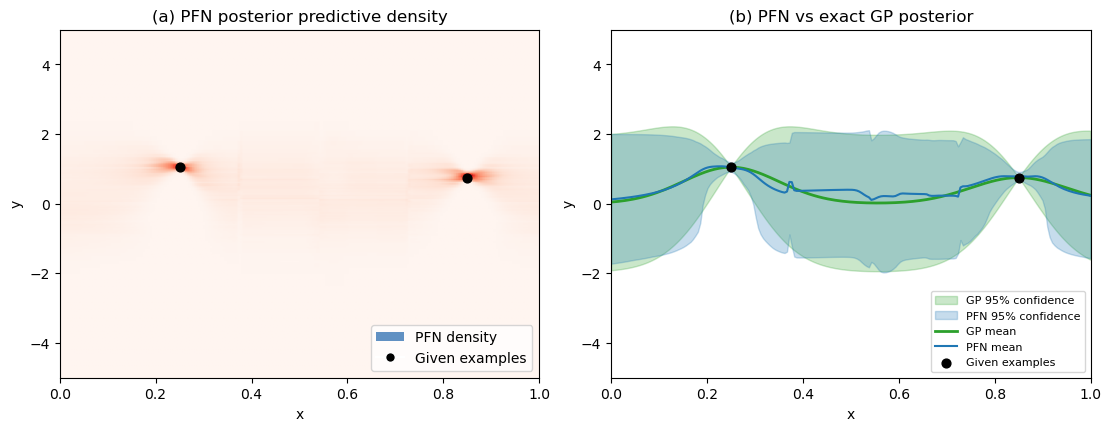

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

# Panel (a): PFN density heatmap.
ax = axes[0]
extent = [x_query.min(), x_query.max(), y_grid.min(), y_grid.max()]
ax.imshow(pfn_density.T, origin='lower', extent=extent, aspect='auto', cmap='Blues')
ax.scatter(X_tr.flatten(), y_tr, c='black', s=40, zorder=5, label='Given examples')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('(a) PFN posterior predictive density')
ax.set_xlim(0, 1); ax.set_ylim(y_grid.min(), y_grid.max())
legend_a = [
    Patch(facecolor='#3a76b5', edgecolor='none', alpha=0.8, label='PFN density'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black', markersize=7, label='Given examples'),
]
ax.legend(handles=legend_a, loc='lower right')

# Panel (b): PFN vs exact GP, mean + 95% CI.
ax = axes[1]
x_flat = x_query.flatten()
ax.fill_between(x_flat, gp_lo, gp_hi,  color='tab:green', alpha=0.25, label='GP 95% confidence')
ax.fill_between(x_flat, pfn_lo, pfn_hi, color='tab:blue',  alpha=0.25, label='PFN 95% confidence')
ax.plot(x_flat, gp_mean,  color='tab:green', lw=2.0, label='GP mean')
ax.plot(x_flat, pfn_mean, color='tab:blue',  lw=1.5, label='PFN mean')
ax.scatter(X_tr.flatten(), y_tr, c='black', s=40, zorder=5, label='Given examples')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('(b) PFN vs exact GP posterior')
ax.set_xlim(0, 1); ax.set_ylim(y_grid.min(), y_grid.max())
ax.legend(loc='lower right', fontsize=8)

fig.savefig('figure3_reproduction.png', dpi=200)
plt.show()

## 7. Verification (sanity checks)

These assertions self-fail if the reproduction visibly regresses.

In [7]:
# At each conditioning x, the PFN mean should be close to the observed y, and the CI should be tight.
anchor_idx = [int(round(0.25 * (len(x_query)-1))), int(round(0.85 * (len(x_query)-1)))]
for ai, expected in zip(anchor_idx, y_tr):
    err = abs(float(pfn_mean[ai]) - float(expected))
    width = float(pfn_hi[ai]) - float(pfn_lo[ai])
    print(f'x={x_query[ai,0]:.2f}  pfn_mean={pfn_mean[ai]:.3f} (target {expected:.3f}, |err|={err:.3f})  CI width={width:.3f}')

# Quantitative: PFN mean tracks GP mean.
mae = float(np.mean(np.abs(pfn_mean - gp_mean)))
print(f'MAE(PFN mean, GP mean) = {mae:.4f}')
if PRESET == 'default':
    # Generous threshold: small/educational repo, not 4M-dataset paper run.
    assert mae < 0.25, f'PFN mean diverges from exact GP (MAE {mae:.3f}); train longer or check hyperparams.'

x=0.25  pfn_mean=1.044 (target 1.050, |err|=0.006)  CI width=0.259
x=0.85  pfn_mean=0.790 (target 0.750, |err|=0.040)  CI width=0.244
MAE(PFN mean, GP mean) = 0.1098
